这里说频率是指一个机场航班出现的频率

## 加载数据

数据已经预处理过了

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_2023_2024_05.csv', dtype={'aircraft': str})

# 查看前几行数据，确保加载成功
print(data.head())

print(data.info())

         flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0  KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1  P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2  mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3  jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4  izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   

              a             b  ...  year  month  day  weekday  hour  minute  \
0  KNqX4/Q5Noc=  HexFWXqbb8I=  ...  2023     10    1        6    12      15   
1  AKQNtuL5r6Q=  Mv6HkAiSLUk=  ...  2023     10    1        6    20      10   
2  n465JzB8Rrw=  N4hmDZN/CJQ=  ...  2023     10    1        6    16      45   
3  N4hmDZN/CJQ=  n465JzB8Rrw=  ...  2023     10    1        6    19      40   
4  5t+HPO9Mu/w=  X5e5r3CS4OA=  ...  2023     10    1        6    13       5   

   second          from            to   unit_price  
0       0  KNqX4/Q5Noc=  HexFWXqbb8I=  

## 编码分类变量

### 新增城市标签

In [2]:
import json
# 加载字典
with open('../../data-hh/my/encoder/city_labels_航班频率加权图标签.json', 'r') as file:
    city_labels_loaded = json.load(file)

print("加载的字典：", city_labels_loaded)

加载的字典： {'+3eoTOkHfoU=': 1, '0Koyk9pJc0s=': 1, '4j3sFPu6XuA=': 1, '9obCP1myMDU=': 2, 'AqmhSoBTk6M=': 1, 'CnmNtb5MOJA=': 0, 'DInJHXgQayE=': 1, 'EIsXRbFUH34=': 1, 'M5N2PVmv8L0=': 1, 'MSFyivV4ETI=': 1, 'N4hmDZN/CJQ=': 0, 'UO2RniR7lJ8=': 1, 'XUXDuFGVfBM=': 1, 'ZCvDTbZuS8Q=': 1, 'gK3uAaRHrOs=': 2, 'jVYRvyHjuvM=': 1, '+O1iBQtlFGU=': 2, '/M8gHzjxpNU=': 2, '0J4jz5aCatU=': 0, 'AKQNtuL5r6Q=': 0, 'AlGb30xUGAU=': 2, 'C3VfOpfT580=': 0, 'Eg2bemFsI9I=': 0, 'FWD6O2fHsIU=': 0, 'KETr2NAmAHE=': 2, 'KFsTKxkC/6g=': 0, 'Qe7TEMbQt6o=': 2, 'QyEgIt0M8Sg=': 0, 'So/c8CkA/Xs=': 2, 'a2cXIUGpIbw=': 2, 'g1hKMyP1V8I=': 0, 'iX2Pe2pxiqQ=': 2, 'lI1bSVMW3Tg=': 2, 'mljW2xeLSiI=': 2, 'tKjndGSl9NQ=': 2, 'vbo2dwBOeps=': 2, 'yypkiQCX5lk=': 2, '+S5aV4Y0s8w=': 0, 'Szk6NJM5C9Y=': 0, 'hwin1ipuzwk=': 2, 'nJFTk7JNmpw=': 2, 'wSF4qXvI044=': 0, 'xIqe+QQIQXQ=': 0, 'zwVGiYamVc0=': 0, '+cjxQ01BFmw=': 2, 'MeDwT1+vyYg=': 2, '/qxKZMQeBus=': 0, '07fT2dsZOJM=': 0, '1/9nd1jNCE0=': 0, '2WRfpdopfDw=': 0, '3nMB4t9SNGw=': 0, '4J2zqjPuTyI=': 2, '4Li

In [3]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

### 新增城市二维嵌入

In [4]:
import json

# 加载字典
with open('../../data-hh/my/encoder/城市嵌入编码_航班频率加权图.json', 'r') as file:
    city_embeddings = json.load(file)

print("加载的字典：", city_embeddings)


加载的字典： {'+3eoTOkHfoU=': [2.048029899597168, 0.11681762337684631], '0Koyk9pJc0s=': [2.684593915939331, -0.11363507062196732], '4j3sFPu6XuA=': [2.1970198154449463, -0.07856795191764832], '9obCP1myMDU=': [-0.2154466211795807, -0.33637043833732605], 'AqmhSoBTk6M=': [2.2669944763183594, 0.26208800077438354], 'CnmNtb5MOJA=': [-0.4401859641075134, 0.17958064377307892], 'DInJHXgQayE=': [2.3286147117614746, 0.5140590071678162], 'EIsXRbFUH34=': [2.43149995803833, 0.18053443729877472], 'M5N2PVmv8L0=': [2.1609177589416504, -0.055703360587358475], 'MSFyivV4ETI=': [2.238361358642578, -0.03455201908946037], 'N4hmDZN/CJQ=': [0.21004608273506165, 0.19061796367168427], 'UO2RniR7lJ8=': [2.4795377254486084, 0.1261746883392334], 'XUXDuFGVfBM=': [1.4508037567138672, -0.21108552813529968], 'ZCvDTbZuS8Q=': [1.9107831716537476, -0.058400288224220276], 'gK3uAaRHrOs=': [0.21883520483970642, -0.47537991404533386], 'jVYRvyHjuvM=': [2.210099458694458, 0.08308106660842896], '+O1iBQtlFGU=': [0.9490273594856262, -0.35

In [5]:
import pandas as pd
import numpy as np

# 将 city_embeddings 转换为 DataFrame
embedding_df = pd.DataFrame.from_dict(city_embeddings, orient='index', columns=['embedding_1', 'embedding_2'])
embedding_df.index.name = 'city'

# 用 'a', 'b', 'c', 'from', 'to' 字段与 embedding_df 合并
data = data.merge(embedding_df, left_on='a', right_index=True, how='left')
data.rename(columns={'embedding_1': 'a_embedding_1', 'embedding_2': 'a_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='b', right_index=True, how='left')
data.rename(columns={'embedding_1': 'b_embedding_1', 'embedding_2': 'b_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='c', right_index=True, how='left')
data.rename(columns={'embedding_1': 'c_embedding_1', 'embedding_2': 'c_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='from', right_index=True, how='left')
data.rename(columns={'embedding_1': 'from_embedding_1', 'embedding_2': 'from_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='to', right_index=True, how='left')
data.rename(columns={'embedding_1': 'to_embedding_1', 'embedding_2': 'to_embedding_2'}, inplace=True)

# 查看添加的新列
print(data[['a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']])


         a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  \
0            -0.269934      -0.835369      -0.041621      -0.432309   
1            -0.176544      -0.169395      -0.242009      -0.233759   
2             0.271668      -0.224615       0.210046       0.190618   
3             0.210046       0.190618       0.271668      -0.224615   
4             0.370946      -1.134758      -0.076694      -1.060626   
...                ...            ...            ...            ...   
5937174      -0.351741       0.201825      -0.393555      -0.449093   
5937175      -0.393555      -0.449093      -0.351741       0.201825   
5937176      -0.351741       0.201825      -0.393555      -0.449093   
5937177      -0.393555      -0.449093      -0.211869      -0.061071   
5937178      -0.211869      -0.061071      -0.393555      -0.449093   

         c_embedding_1  c_embedding_2  from_embedding_1  from_embedding_2  \
0                  NaN            NaN         -0.269934         -0.835

### 统计不同城市的频率

In [6]:
# 将 from 和 to 两列合并，并统计每个城市的出现次数
city_count_series = pd.concat([data['from'], data['to']]).value_counts()

# 转换为 city_count 数据框
city_count = city_count_series.reset_index()
city_count.columns = ['city', 'count']

# 3. 创建 city_map，将每个城市映射为其出现次数（或者任何你需要的值）
city_map = dict(zip(city_count['city'], city_count['count']))

# 输出结果
print(city_count)

             city   count
0    vbo2dwBOeps=  465140
1    /M8gHzjxpNU=  438945
2    gK3uAaRHrOs=  428876
3    So/c8CkA/Xs=  413574
4    0J4jz5aCatU=  392721
..            ...     ...
247  wbf1sxPhwNM=     148
248  Qejm7YTJTI4=     146
249  DwCmftDLjPw=     114
250  Eed3EdkMDqg=      50
251  MgrS1LT2KO4=      44

[252 rows x 2 columns]


使用 json 保存和加载 city_map

In [7]:
import json

# 保存 city_map 到 JSON 文件
with open('../../data-hh/my/encoder/city_map_频率编码.json', 'w') as f:
    json.dump(city_map, f)

print("city_map_频率编码 已保存到 city_map_频率编码")

city_map_频率编码 已保存到 city_map_频率编码


### 对'a', 'b', 'c', 'from', 'to'进行频率编码

In [8]:
# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)

# 输出结果
print(city_count)
print(data)

             city   count
0    vbo2dwBOeps=  465140
1    /M8gHzjxpNU=  438945
2    gK3uAaRHrOs=  428876
3    So/c8CkA/Xs=  413574
4    0J4jz5aCatU=  392721
..            ...     ...
247  wbf1sxPhwNM=     148
248  Qejm7YTJTI4=     146
249  DwCmftDLjPw=     114
250  Eed3EdkMDqg=      50
251  MgrS1LT2KO4=      44

[252 rows x 2 columns]
               flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0        KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1        P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2        mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3        jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4        izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   
...               ...     ...    ...      ...   ...     ...       ...  ...   
5937174  BzUm4im0EqA=      窄体  152.0      320     1       1      3.03   99   
5937175  w+GXbx7u3EM=      窄体  152.0    

### 对'flt_no', 'bd_type', 'aircraft'进行标签编码

In [9]:
data.head(5)

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,pax,a,b,...,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
0,KgJrsp7Jd78=,窄体,132.0,319,1,1,1.07,25,29186.0,2740.0,...,-0.269934,-0.835369,-0.041621,-0.432309,NaN,NaN,-0.269934,-0.835369,-0.041621,-0.432309
1,P9IRwar34h0=,窄体,189.0,321,1,1,1.38,151,247850.0,13629.0,...,-0.176544,-0.169395,-0.242009,-0.233759,NaN,NaN,-0.176544,-0.169395,-0.242009,-0.233759
2,mJitm0UDfM4=,窄体,132.0,319,1,1,1.57,38,3608.0,189423.0,...,0.271668,-0.224615,0.210046,0.190618,NaN,NaN,0.271668,-0.224615,0.210046,0.190618
3,jXr97M1wpn4=,窄体,132.0,319,1,1,1.58,109,189423.0,3608.0,...,0.210046,0.190618,0.271668,-0.224615,NaN,NaN,0.210046,0.190618,0.271668,-0.224615
4,izjfHOxAho4=,窄体,132.0,319,1,1,1.80,124,64876.0,26471.0,...,0.370946,-1.134758,-0.076694,-1.060626,NaN,NaN,0.370946,-1.134758,-0.076694,-1.060626


In [10]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
# categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 创建并应用 LabelEncoder
label_encoders = {}

# 创建保存编码器的文件夹（如果文件夹不存在）
save_folder = '../../data-hh/my/encoder/'
os.makedirs(save_folder, exist_ok=True)  # 如果文件夹已存在，不会报错

# 遍历每个分类特征，使用 LabelEncoder 对其进行编码
for col in categorical_columns:
    le = LabelEncoder()  # 创建一个 LabelEncoder 实例
    data[col] = le.fit_transform(data[col])  # 对训练数据中的分类特征进行编码
    label_encoders[col] = le  # 将每个特征的编码器保存到字典中，方便后续使用

    # 保存每个编码器到指定文件夹
    encoder_path = os.path.join(save_folder, f"{col}_encoder_all.pkl")  # 构建保存路径
    joblib.dump(le, encoder_path)  # 使用 joblib 将编码器保存为 pkl 文件
    print(f"{col} 的编码器已保存为 {encoder_path}")  # 输出保存的路径

flt_no 的编码器已保存为 ../../data-hh/my/encoder/flt_no_encoder_all.pkl
bd_type 的编码器已保存为 ../../data-hh/my/encoder/bd_type_encoder_all.pkl
aircraft 的编码器已保存为 ../../data-hh/my/encoder/aircraft_encoder_all.pkl


## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [11]:
# 特征列
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft',  'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','holiday', 'hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label']]

# 有abc，有标签，有嵌入
X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 删除了abc，但有标签，有嵌入
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 目标列
y = data['pax']

In [12]:
test_x = X.head(1)
test_x

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,a,b,c,...,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
0,4013,3,132.0,1,1,1,1.07,29186.0,2740.0,NaN,...,-0.269934,-0.835369,-0.041621,-0.432309,NaN,NaN,-0.269934,-0.835369,-0.041621,-0.432309


In [13]:
y.head(5)

0     25
1    151
2     38
3    109
4    124
Name: pax, dtype: int64

### 对x进行标准化

In [14]:
from sklearn.preprocessing import StandardScaler

# 对所有特征进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将标准化后的数据转回 DataFrame 格式
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 查看结果
pd.set_option('display.max_columns', None)  # 显示所有列
print(X_scaled.head(1))


# 保存 scaler
joblib.dump(scaler, '../../data-hh/my/encoder/standard_scaler_x.pkl')
print("x的标准化器已保存为 standard_scaler_x.pkl")

     flt_no   bd_type       cap  aircraft     legs    leg_no  duration  \
0 -0.492818  0.303017 -1.072555 -1.186428 -0.80514 -0.554166   -1.2639   

          a         b   c      year     month       day   weekday      hour  \
0 -1.462394 -1.405325 NaN -0.648036  1.338679 -1.685647  1.494105 -0.349123   

     minute  second      from        to  unit_price   a_label   b_label  \
0 -0.630404     0.0 -1.375902 -1.558266    1.148053  1.180184  1.275298   

   c_label  from_label  to_label  a_embedding_1  a_embedding_2  b_embedding_1  \
0      NaN    1.209868  1.211753      -0.023835      -1.618333       0.370465   

   b_embedding_2  c_embedding_1  c_embedding_2  from_embedding_1  \
0      -0.716107            NaN            NaN         -0.040575   

   from_embedding_2  to_embedding_1  to_embedding_2  
0         -1.636646        0.374835       -0.700104  
x的标准化器已保存为 standard_scaler_x.pkl


In [15]:
# 获取第一行的关键信息
first_row = X_scaled.head(1)
flt_no = first_row['flt_no'].values[0]  # 假设flt_no是索引
year = first_row['year'].values[0]
month = first_row['month'].values[0]
day = first_row['day'].values[0]

# 筛选出相同航班和日期的所有行
filtered_rows = X_scaled[
    (X_scaled['flt_no'] == flt_no) &  # 相同航班号
    (X_scaled['year'] == year) &   # 相同年份
    (X_scaled['month'] == month) & # 相同月份
    (X_scaled['day'] == day)       # 相同日期
]

print("筛选结果：")
print(filtered_rows)

筛选结果：
     flt_no   bd_type       cap  aircraft     legs    leg_no  duration  \
0 -0.492818  0.303017 -1.072555 -1.186428 -0.80514 -0.554166   -1.2639   

          a         b   c      year     month       day   weekday      hour  \
0 -1.462394 -1.405325 NaN -0.648036  1.338679 -1.685647  1.494105 -0.349123   

     minute  second      from        to  unit_price   a_label   b_label  \
0 -0.630404     0.0 -1.375902 -1.558266    1.148053  1.180184  1.275298   

   c_label  from_label  to_label  a_embedding_1  a_embedding_2  b_embedding_1  \
0      NaN    1.209868  1.211753      -0.023835      -1.618333       0.370465   

   b_embedding_2  c_embedding_1  c_embedding_2  from_embedding_1  \
0      -0.716107            NaN            NaN         -0.040575   

   from_embedding_2  to_embedding_1  to_embedding_2  
0         -1.636646        0.374835       -0.700104  


### 对y进行标准化

In [16]:
# 对目标列 y 进行标准化
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # 将 y 转换为 2D 数组进行标准化

# 转换回 DataFrame 格式
y_scaled = pd.DataFrame(y_scaled, columns=['pax_scaled'])

# 查看标准化后的 y
print(y_scaled.head())

# 保存 y 的 scaler
joblib.dump(scaler_y, '../../data-hh/my/encoder/standard_scaler_y.pkl')
print("y的标准化器已保存为 standard_scaler_y.pkl")

   pax_scaled
0   -1.689896
1    0.862217
2   -1.426583
3    0.011513
4    0.315336
y的标准化器已保存为 standard_scaler_y.pkl


## 训练XGBoost模型

In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 自定义 SMAPE 函数
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return np.mean(diff / denominator) * 100

# 自定义评估函数
def smape_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    smape_value = smape(y_true, y_pred)
    return 'SMAPE', smape_value

# 数据划分
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 输出数据集大小
print(f'训练集大小: {X_train.shape[0]}')
print(f'验证集大小: {X_val.shape[0]}')
print(f'测试集大小: {X_test.shape[0]}')

# 转换为 DMatrix 格式
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# 设置参数
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.2,
    'max_depth': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'alpha': 1,
    "lambda":1
}

# 设置评估集
evals = [(dtrain, 'train'), (dval, 'validation')]

# 训练模型，使用自定义评估指标
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=10,
    custom_metric=smape_eval,  # 使用 custom_metric 参数
    verbose_eval=10 #隔多少轮显示一次
)

# 预测测试集
y_pred = model.predict(dtest)

# # 测试集 SMAPE 评估
# test_smape = smape(y_test, y_pred)
# print(f'SMAPE on Test Set: {test_smape:.2f}%')

# # 测试集 MSE 评估
# mse = mean_squared_error(y_test, y_pred)
# print(f'Mean Squared Error on Test Set: {mse}')


训练集大小: 4749743
验证集大小: 593718
测试集大小: 593718
[0]	train-rmse:0.87093	train-SMAPE:151.16084	validation-rmse:0.86993	validation-SMAPE:151.18731
[10]	train-rmse:0.53848	train-SMAPE:85.19678	validation-rmse:0.53928	validation-SMAPE:85.37193
[20]	train-rmse:0.50103	train-SMAPE:79.71589	validation-rmse:0.50330	validation-SMAPE:79.97311
[30]	train-rmse:0.48477	train-SMAPE:77.60681	validation-rmse:0.48805	validation-SMAPE:77.99870
[40]	train-rmse:0.47373	train-SMAPE:76.23192	validation-rmse:0.47789	validation-SMAPE:76.70852
[50]	train-rmse:0.46587	train-SMAPE:75.18332	validation-rmse:0.47063	validation-SMAPE:75.72005
[60]	train-rmse:0.45940	train-SMAPE:74.36882	validation-rmse:0.46486	validation-SMAPE:74.96457
[70]	train-rmse:0.45487	train-SMAPE:73.75728	validation-rmse:0.46085	validation-SMAPE:74.41202
[80]	train-rmse:0.44851	train-SMAPE:72.92709	validation-rmse:0.45519	validation-SMAPE:73.66905
[90]	train-rmse:0.44498	train-SMAPE:72.42044	validation-rmse:0.45211	validation-SMAPE:73.21777
[100]	

In [18]:
y_pred

array([ 0.00945841, -0.6061565 ,  0.5786823 , ...,  0.00786656,
        0.18583444,  0.09410127], dtype=float32)

In [19]:
# 反标准化 y_test
y_test_original = scaler_y.inverse_transform(y_test.values.reshape(-1, 1))

# 反标准化预测结果 y_pred
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

In [20]:
y_test_original



array([[ 71.],
       [ 82.],
       [149.],
       ...,
       [151.],
       [127.],
       [124.]])

In [21]:
y_pred_original

array([[108.89858 ],
       [ 78.50515 ],
       [137.00165 ],
       ...,
       [108.81999 ],
       [117.606415],
       [113.07747 ]], dtype=float32)

In [22]:
# 正确的写法
test_results = list(zip(y_test_original[:100], y_pred_original[:100]))  # 真实值和预测值

print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results[:40]):
    # 如果是多维数组，使用 .item() 转换为标量
    true_value = true_value.item() if isinstance(true_value, np.ndarray) else true_value
    pred_value = pred_value.item() if isinstance(pred_value, np.ndarray) else pred_value
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")



20条测试结果（真实值 vs 预测值）:
第1条: 真实值=71.0, 预测值=108.90
第2条: 真实值=82.0, 预测值=78.51
第3条: 真实值=149.0, 预测值=137.00
第4条: 真实值=166.0, 预测值=144.95
第5条: 真实值=74.0, 预测值=85.94
第6条: 真实值=86.0, 预测值=64.31
第7条: 真实值=65.0, 预测值=93.91
第8条: 真实值=142.0, 预测值=123.96
第9条: 真实值=54.0, 预测值=42.61
第10条: 真实值=152.0, 预测值=180.63
第11条: 真实值=185.0, 预测值=169.22
第12条: 真实值=7.0, 预测值=14.41
第13条: 真实值=89.0, 预测值=105.12
第14条: 真实值=76.0, 预测值=56.86
第15条: 真实值=164.0, 预测值=164.70
第16条: 真实值=179.0, 预测值=163.11
第17条: 真实值=70.0, 预测值=100.83
第18条: 真实值=86.0, 预测值=84.08
第19条: 真实值=77.0, 预测值=114.27
第20条: 真实值=43.0, 预测值=32.06
第21条: 真实值=140.0, 预测值=146.64
第22条: 真实值=78.0, 预测值=119.06
第23条: 真实值=71.0, 预测值=64.77
第24条: 真实值=182.0, 预测值=170.74
第25条: 真实值=148.0, 预测值=159.40
第26条: 真实值=132.0, 预测值=94.29
第27条: 真实值=187.0, 预测值=195.77
第28条: 真实值=88.0, 预测值=105.89
第29条: 真实值=62.0, 预测值=83.23
第30条: 真实值=70.0, 预测值=122.91
第31条: 真实值=108.0, 预测值=134.56
第32条: 真实值=65.0, 预测值=88.96
第33条: 真实值=88.0, 预测值=74.73
第34条: 真实值=113.0, 预测值=109.89
第35条: 真实值=109.0, 预测值=119.47
第36条: 真实值=38.0, 预测值=39.71
第37条: 真实值=81.0, 

In [23]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_pred - y_true)
    
    # 避免除以零，将分母中为零的项替换为一个小值
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = 100 * np.mean(diff / denominator)
    return smape


def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    
    # 避免除以零，将 y_true 中的零值替换为一个小值
    y_true = np.where(y_true == 0, 1e-8, y_true)
    
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape


# 假设 y_test 和 y_pred 已经是标准化反归一化后的数据
# 将其转换为一维数组以确保形状一致
y_test = np.array(y_test_original).ravel()
y_pred = np.array(y_pred_original).ravel()

# 评估指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')
print(f'R-squared (R²): {r2:.4f}')


Mean Squared Error (MSE): 367.9664
Root Mean Squared Error (RMSE): 19.1825
Mean Absolute Error (MAE): 14.4709
Mean Absolute Percentage Error (MAPE): 25.2644%
Symmetric Mean Absolute Percentage Error (SMAPE): 18.1620%
R-squared (R²): 0.8492


似乎对于较小值预测存在误差

In [24]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 367.9664
Root Mean Squared Error (RMSE): 19.1825
Mean Absolute Error (MAE): 14.4709
Mean Absolute Percentage Error (MAPE): 25.2644%
Symmetric Mean Absolute Percentage Error (SMAPE): 18.1620%


## 保存模型

In [26]:
model.save_model("../../data-hh/my/模型文件/频率编码/归一化_xgboost_model_1000.json")
print("模型已保存为 xgboost_model_1000.json")

模型已保存为 xgboost_model_1000.json


In [27]:
# 将筛选结果转换为DMatrix并预测
dtest = xgb.DMatrix(filtered_rows)
scaled_predictions = model.predict(dtest)
scaled_predictions_2d = scaled_predictions.reshape(-1, 1)
predictions = scaler_y.inverse_transform(scaled_predictions_2d)

print("\n预测结果：")
for i, pred in enumerate(predictions):
    print(f"航段 {i+1}: {pred[0]:.2f}")


预测结果：
航段 1: 33.20


## 超参数设置

## 不同特征重要程度测试

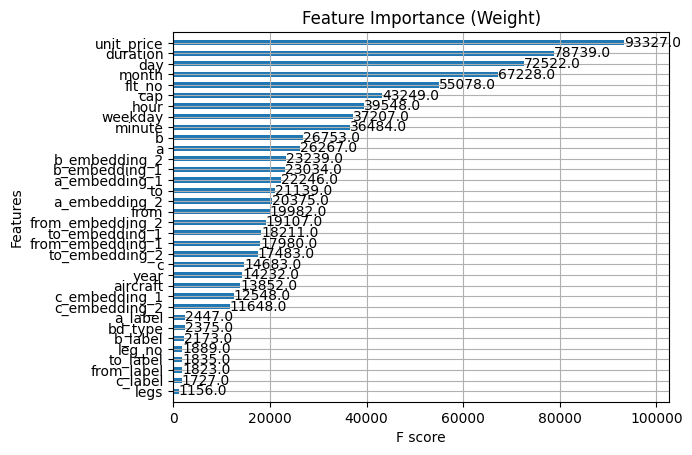

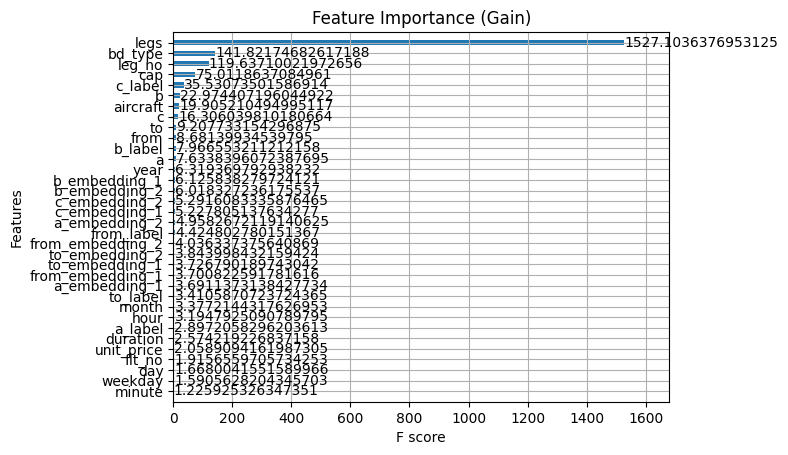

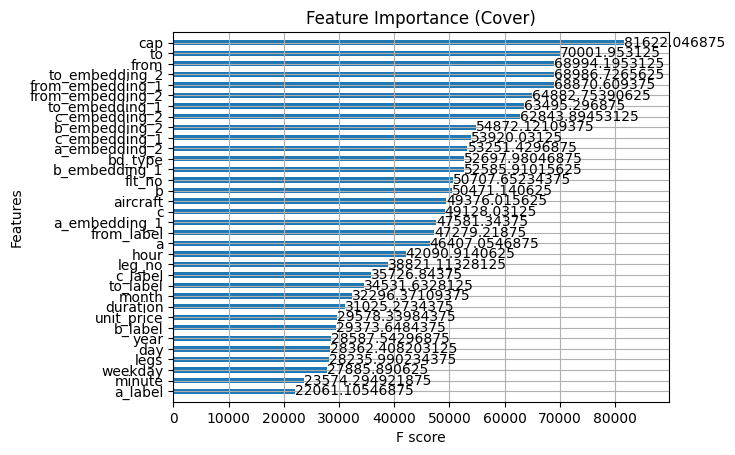

In [28]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 假设 model 是训练好的 XGBoost 模型
xgb.plot_importance(model, importance_type='weight', title="Feature Importance (Weight)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='gain', title="Feature Importance (Gain)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='cover', title="Feature Importance (Cover)", height=0.5)
plt.show()